0#%% md
# Dimensioning a village battery for [Solbyn](https://solbyn.org/)

Knowns:
* AC cables connecting (in decreasing order of energy):
  1. A windmill far outside the village, outside the village AC voltage transformer.
  2. Northern and southern half-village with 25 households. All with hot-water accumulators. Many with wood stoves. Some with PEV panels. One with a solar heat panel.
  3. Eastern installation: PEV panels, solar heat panels, a large hot-water accumulator, a washing facility, a kindergarten, a cafeteria, a guest apartment.
  4. Western installation: PEV panels, 14 kWh electric battery and 20 EVs.
  5. Electric outdoor lighting.
* Data on power transfers to one household.
* Data on power transfers to and from the village except the windmill and households.

Suggestions:
* Increase electric battery to 36 kWh.
* Load-balance all households within each 10 buildings.
* Upgrade EV chargers to support vehicle-to-grid (VTG/VTX).
* Load-balance everything except the windmill.
* Load-balance everything including the windmill.

General questions:
* How many years can we expect before pay-off of a battery capacity increase to 36 kWh?
* Would the battery investment make sense with VTG?
* Would the battery investment make sense with everything except the windmill balanced?
* Would the battery investment make sense with everything including the windmill balanced?

First task:
* Is a flat electricity energy daily consumption a relevant approximation for dimensioning a battery that may later be used by all 50 households too?
* Use https://github.com/Arcascope/circadian to calculate daily and nightly energy transfers!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as lines
from circadian.plots import Actogram
from circadian.lights import LightSchedule
from circadian.models import Forger99, Jewett99, Hannay19, Hannay19TP

In [ ]:
days_night = 3
days_day = 2
slam_shift = LightSchedule.ShiftWork(lux=300.0, days_on=days_night, days_off=days_day)

total_days = 30
time = np.arange(0, 24*total_days, 0.10)
light_values = slam_shift(time)

f_model = Forger99()
kj_model = Jewett99()
spm_model = Hannay19()
tpm_model = Hannay19TP()

equilibration_reps = 2
initial_conditions_forger = f_model.equilibrate(time, light_values, equilibration_reps)
initial_conditions_kj = kj_model.equilibrate(time, light_values, equilibration_reps)
initial_conditions_spm = spm_model.equilibrate(time, light_values, equilibration_reps)
initial_conditions_tpm = tpm_model.equilibrate(time, light_values, equilibration_reps)

E:\home\joakimbits\village_battery\.venv\Lib\site-packages\circadian\models.py:431: UserWarning: The model did not equilibrate. Try increasing the number of loops.
  warnings.warn("The model did not equilibrate. Try increasing the number of loops.")


KeyboardInterrupt: 

In [3]:
trajectory_f = f_model(time, initial_conditions_forger, light_values)
trajectory_kj = kj_model(time, initial_conditions_kj, light_values)
trajectory_spm = spm_model(time, initial_conditions_spm, light_values)
trajectory_tpm = tpm_model(time, initial_conditions_tpm, light_values)

In [4]:
dlmo_f = f_model.dlmos()
dlmo_kj = kj_model.dlmos()
dlmo_spm = spm_model.dlmos()
dlmo_tpm = tpm_model.dlmos()

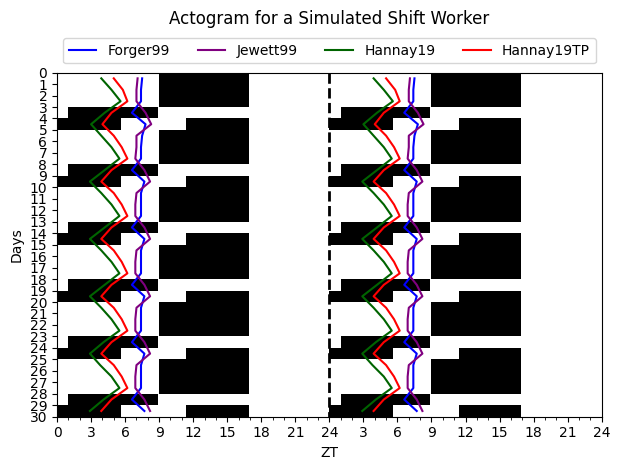

In [5]:
acto = Actogram(time, light_vals=light_values, opacity=1.0, smooth=False)
acto.plot_phasemarker(dlmo_f, color='blue')
acto.plot_phasemarker(dlmo_spm, color='darkgreen')
acto.plot_phasemarker(dlmo_tpm, color='red')
acto.plot_phasemarker(dlmo_kj, color='purple')
# legend
blue_line = lines.Line2D([], [], color='blue', label='Forger99')
green_line = lines.Line2D([], [], color='darkgreen', label='Hannay19')
red_line = lines.Line2D([], [], color='red', label='Hannay19TP')
purple_line = lines.Line2D([], [], color='purple', label='Jewett99')

plt.legend(handles=[blue_line, purple_line, green_line, red_line],
           loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4)
plt.title("Actogram for a Simulated Shift Worker", pad=35)
plt.tight_layout()
plt.show()

In [6]:
import circadian.readers

In [7]:
help(circadian.readers)

Help on module circadian.readers in circadian:

NAME
    circadian.readers - Defines several methods for analyzing, plotting, and exporting wearable data, including a Pandas accessor for wearable dataframes

CLASSES
    builtins.object
        WearableData

    class WearableData(builtins.object)
     |  WearableData(pandas_obj)
     |
     |  pd.DataFrame accessor implementing wearable-specific methods
     |
     |  Methods defined here:
     |
     |  __init__(self, pandas_obj)
     |      Initialize self.  See help(type(self)) for accurate signature.
     |
     |  add_metadata(self, metadata: Dict[str, str], inplace: bool = False)
     |
     |  is_valid(self)
     |
     |  ----------------------------------------------------------------------
     |  Static methods defined here:
     |
     |  rename_columns(df, inplace: bool = False)
     |      Standardize column names by making them lowercase and replacing spaces with underscores
     |
     |  -------------------------------

In [2]:
import pandas as pd

In [3]:
# Import with closest latitude/longitude time zone for Solbyn as default
TZ = 'Europe/Copenhagen'
def read_european_table(dataset: str, datum='Datum', tz=TZ) -> pd.DataFrame:
    df = pd.read_table(dataset, sep=';', decimal=',', index_col=datum, parse_dates=[datum], na_values=["-", "—"])
    df.index = df.index.tz_localize(tz, nonexistent="shift_forward", ambiguous="NaT")
    return df


In [4]:
systems = read_european_table('data/El - Sandbyvägen 196, Dalby.csv')
household = read_european_table('data/El - Sandbyvägen 158, Dalby.csv')

In [6]:
systems.head()

,Produktion,El kWh,Utomhustemperatur,kWh - 2023-01-01 - 2023-12-31,T(°C) - 2023-01-01 - 2023-12-31
Datum,,,,,
2024-01-01 00:00:00+01:00,0.0,6.17,4.2,8.79,5.7
2024-01-01 01:00:00+01:00,0.0,6.12,4.1,8.71,6.0
2024-01-01 02:00:00+01:00,0.0,5.61,3.9,7.95,6.6
2024-01-01 03:00:00+01:00,0.0,5.86,3.8,5.28,6.5
2024-01-01 04:00:00+01:00,0.0,5.91,3.8,5.84,5.9


In [7]:
household.head()

,El kWh,Utomhustemperatur,kWh - 2023-01-01 - 2023-12-31,T(°C) - 2023-01-01 - 2023-12-31
Datum,,,,
2024-01-01 00:00:00+01:00,1.412,4.2,1.148,5.7
2024-01-01 01:00:00+01:00,1.219,4.1,0.856,6.0
2024-01-01 02:00:00+01:00,2.172,3.9,0.891,6.6
2024-01-01 03:00:00+01:00,2.133,3.8,1.238,6.5
2024-01-01 04:00:00+01:00,1.179,3.8,1.187,5.9


In [8]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="village_battery")
location = geolocator.geocode("Sandbyvägen 196, Dalby, Sweden")
location

Location(196, Sandbyvägen, Dalby, Lunds kommun, Skåne län, 247 51, Sverige, (55.6731593, 13.3532784, 0.0))

In [9]:
import requests

latitude, longitude, _ = location.point
OPENTOPO = "https://api.opentopodata.org/v1/"
elevation = float(requests.get(f"{OPENTOPO}aster30m?locations={latitude},{longitude}").json()['results'][0]['elevation'])
elevation

86.0

In [10]:
from pvlib import location, solarposition, irradiance

site = location.Location(latitude=latitude, longitude=longitude, tz=TZ, altitude=elevation, name="Solbyn")
site

Location: 
  name: Solbyn
  latitude: 55.6731593
  longitude: 13.3532784
  altitude: 86.0
  tz: Europe/Copenhagen

In [12]:
datum = systems.index
clearsky = site.get_clearsky(datum, model="ineichen")
clearsky

,ghi,dni,dhi
Datum,,,
2024-01-01 00:00:00+01:00,0.0,0.0,0.0
2024-01-01 01:00:00+01:00,0.0,0.0,0.0
2024-01-01 02:00:00+01:00,0.0,0.0,0.0
2024-01-01 03:00:00+01:00,0.0,0.0,0.0
2024-01-01 04:00:00+01:00,0.0,0.0,0.0
...,...,...,...
2024-12-31 19:00:00+01:00,0.0,0.0,0.0
2024-12-31 20:00:00+01:00,0.0,0.0,0.0
2024-12-31 21:00:00+01:00,0.0,0.0,0.0


In [13]:
print('>>> systems.head()\n', systems.head())
print('>>> site\n', site)
print('>>> clearsky\n', clearsky)

>>> systems.head()
                            Produktion  El kWh  Utomhustemperatur  \
Datum                                                              
2024-01-01 00:00:00+01:00         0.0    6.17                4.2   
2024-01-01 01:00:00+01:00         0.0    6.12                4.1   
2024-01-01 02:00:00+01:00         0.0    5.61                3.9   
2024-01-01 03:00:00+01:00         0.0    5.86                3.8   
2024-01-01 04:00:00+01:00         0.0    5.91                3.8   

                           kWh - 2023-01-01  - 2023-12-31  \
Datum                                                       
2024-01-01 00:00:00+01:00                            8.79   
2024-01-01 01:00:00+01:00                            8.71   
2024-01-01 02:00:00+01:00                            7.95   
2024-01-01 03:00:00+01:00                            5.28   
2024-01-01 04:00:00+01:00                            5.84   

                           T(°C) - 2023-01-01  - 2023-12-31  
Datum        

In [14]:
TILT_DEG    = 25.0
AZIMUTH_DEG = 135.0   # 0=N, 90=E, 180=S, 270=W → SE = 135°
ALBEDO      = 0.2
K_ILL       = 120.0

In [15]:
solpos = solarposition.get_solarposition(
    time=datum, latitude=latitude, longitude=longitude, altitude=elevation
)

In [16]:
poa = irradiance.get_total_irradiance(
    surface_tilt=TILT_DEG,
    surface_azimuth=AZIMUTH_DEG,
    dni=clearsky["dni"],
    ghi=clearsky["ghi"],
    dhi=clearsky["dhi"],
    solar_zenith=solpos["apparent_zenith"],
    solar_azimuth=solpos["azimuth"],
    albedo=ALBEDO,
)

In [17]:
poa_global = poa["poa_global"]